成功加载: output_cache/class0/BraTS2021_00000_t1.npz
------------------------------
包含的 Keys: ['moments', 'moments_flip']
------------------------------
【数值检查】
形状 (Shape): (4, 16, 16, 16)
数据类型 (Dtype): float32
最小值 (Min): -1.2807
最大值 (Max): 1.2618
均值 (Mean): 0.0554
STD: 0.3884154260158539
✅ 数据数值看起来正常。
------------------------------
【可视化特征图 (取中间切片)】


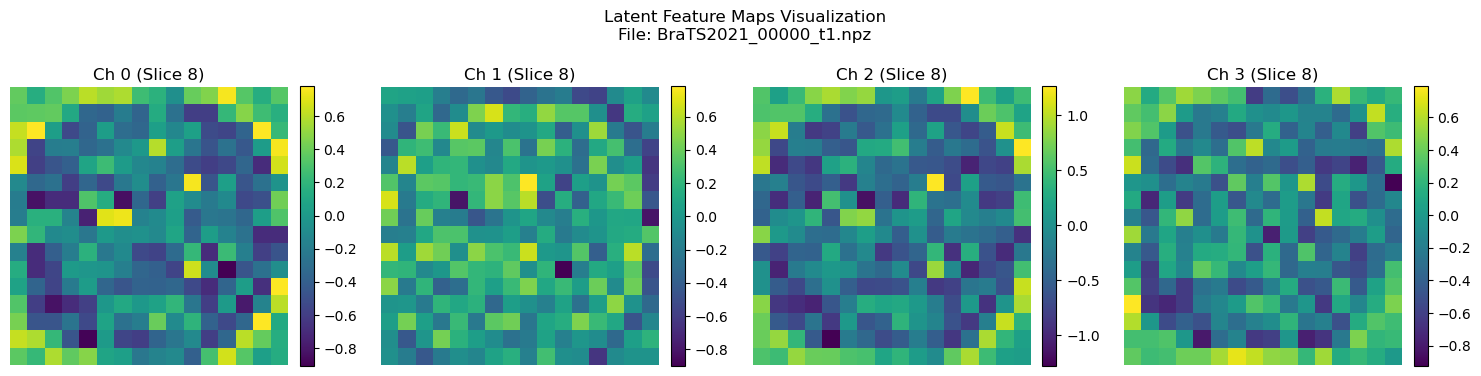

In [1]:
# 检查缓存的 Latent 特征图文件内容

import numpy as np
import matplotlib.pyplot as plt
import os

file_path = "output_cache/class0/BraTS2021_00000_t1.npz"

def inspect_latents(path):
    if not os.path.exists(path):
        print(f"错误: 找不到文件 {path}")
        return

    # 1. 加载文件
    data = np.load(path)
    print(f"成功加载: {path}")
    print("-" * 30)
    
    # 查看里面有哪些键值
    print(f"包含的 Keys: {list(data.keys())}")
    
    # 提取 Latent (moments)
    # moments 通常是原始图像的 Latent，moments_flip 是翻转后的
    latents = data['moments'] 
    
    # 2. 数值检查 (Sanity Check)
    print("-" * 30)
    print("【数值检查】")
    print(f"形状 (Shape): {latents.shape}") # 预期应该是 (4, 16, 16, 16)
    print(f"数据类型 (Dtype): {latents.dtype}")
    print(f"最小值 (Min): {latents.min():.4f}")
    print(f"最大值 (Max): {latents.max():.4f}")
    print(f"均值 (Mean): {latents.mean():.4f}")


    print(f"STD: {np.std(latents)}")

    # 检查是否有 NaN (无效值) 或 全 0
    if np.isnan(latents).any():
        print("❌ 警告: 数据中包含 NaN (无效数值)！模型可能发散了。")
    elif latents.max() == 0 and latents.min() == 0:
        print("❌ 警告: 数据全为 0！可能是输入图像读取失败或全黑。")
    else:
        print("✅ 数据数值看起来正常。")

    # 3. 可视化 (Visualization)
    # 虽然 Latent 是压缩特征，但通常能在通道里看到模糊的“大脑轮廓”
    print("-" * 30)
    print("【可视化特征图 (取中间切片)】")
    
    channels = latents.shape[0]
    depth = latents.shape[1]
    mid_slice = depth // 2
    
    # 绘制每个通道的中间切片
    fig, axes = plt.subplots(1, channels, figsize=(15, 4))
    if channels == 1: axes = [axes] # 兼容单通道情况
    
    for i in range(channels):
        # 取出第 i 个通道，中间深度切片
        img_slice = latents[i, mid_slice, :, :]
        
        ax = axes[i]
        im = ax.imshow(img_slice, cmap='viridis')
        ax.set_title(f"Ch {i} (Slice {mid_slice})")
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.suptitle(f"Latent Feature Maps Visualization\nFile: {os.path.basename(path)}")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    inspect_latents(file_path)